In [146]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import healpy as hp
import copy
from scipy.stats import poisson,norm,chi2

import collections
import os
from pathlib import Path
# from photutils.segmentation import SourceFinder,SourceCatalog,make_2dgaussian_kernel
from astropy.convolution import convolve
import uproot as up
from scipy.interpolate import interp1d
from hawc_hal import HealpixConeROI

In [147]:
def obtain_containment(response_file_path, quantile = 0.68):
    """Get the containment radius from the PSF response file for a given quantile

    :param response_file_path: path to the PSF response file
    :param quantile: quantile for the containment radius
    :return: dictionary of the containment radii for each analysis bin, upper and
    lower edges of the declination bins
    """

    if not Path(response_file_path).exists():
        raise FileNotFoundError(f"File {response_file_path} does not exist")

    with up.open(response_file_path, handler=up.MemmapSource) as response:  # type: ignore
        upper_edges: ndarray = response["DecBins/upperEdge"].array(library="np")  # type: ignore
        lower_edges: ndarray = response["DecBins/lowerEdge"].array(library="np")  # type: ignore

        hawc_dec_bins: list[int] = list(range(upper_edges.size))
        analysis_bins = response["AnalysisBins/name"].array(library="np").astype(str)  # type: ignore

        response_bins_containment = collections.OrderedDict(
            {bin_id: np.empty_like(upper_edges) for bin_id in analysis_bins}
        )

        for bin_id in analysis_bins:
            for dec_bin in hawc_dec_bins:
                psf_hist= response[
                    f"dec_{dec_bin:02d}/nh_{bin_id}/PSF_dec{dec_bin}_nh{bin_id}"
                ].to_boost()  # type: ignore
                xquant = get_quantiles(psf_hist, quantile)
                response_bins_containment[bin_id][dec_bin] = xquant

        return response_bins_containment, upper_edges, lower_edges

def get_quantiles(psf_hist, quantile):# -> float | ndarray:
    """Compute the quantiles of a PSF histogram, the inputs can be a single number or
    a list of desired quantiles. If a list is provided, the function will return an
    array of quantiles. Otherwise, a single number will be returned.

    :param psf_hist: PSF histogram
    :param quantile: desired quantile(s)
    :raises ValueError: raised if the dimensions of the histogram are higher than 1
    :return: location of the quantile(s) in the histogram
    """
    if psf_hist.ndim != 1:
        raise ValueError("Histogram must be 1D")

    pdf = psf_hist.values() / psf_hist.values().sum()
    cdf = np.cumsum(pdf)

    # refined the interpolation to get the exact quantile
    interpolated_quantile = interp1d(psf_hist.axes[0].centers, cdf)
    interp_xvals = np.linspace(
        psf_hist.axes[0].centers[0], psf_hist.axes[0].centers[-1], 500
    )
    if isinstance(quantile, list):
        xquant = np.zeros(len(quantile), dtype=np.float64)
        for i, q in enumerate(quantile):
            xquant_idx = np.argmin(abs(interpolated_quantile(interp_xvals) - q))
            xquant[i] = interp_xvals[xquant_idx]

        return xquant

    xquant: int = np.argmin(np.abs(interpolated_quantile(interp_xvals) - quantile))

    return interp_xvals[xquant]

In [148]:
def obtain_containment(response_file_path, quantile = 0.68):
    """Get the containment radius from the PSF response file for a given quantile

    :param response_file_path: path to the PSF response file
    :param quantile: quantile for the containment radius
    :return: dictionary of the containment radii for each analysis bin, upper and
    lower edges of the declination bins
    """

    if not Path(response_file_path).exists():
        raise FileNotFoundError(f"File {response_file_path} does not exist")

    with up.open(response_file_path, handler=up.MemmapSource) as response:  # type: ignore
        upper_edges: ndarray = response["DecBins/upperEdge"].array(library="np")  # type: ignore
        lower_edges: ndarray = response["DecBins/lowerEdge"].array(library="np")  # type: ignore

        hawc_dec_bins: list[int] = list(range(upper_edges.size))
        analysis_bins = response["AnalysisBins/name"].array(library="np").astype(str)  # type: ignore

        response_bins_containment = collections.OrderedDict(
            {bin_id: np.empty_like(upper_edges) for bin_id in analysis_bins}
        )

        for bin_id in analysis_bins:
            for dec_bin in hawc_dec_bins:
                psf_hist= response[
                    f"dec_{dec_bin:02d}/nh_{bin_id}/PSF_dec{dec_bin}_nh{bin_id}"
                ].to_boost()  # type: ignore
                xquant = get_quantiles(psf_hist, quantile)
                response_bins_containment[bin_id][dec_bin] = xquant

        return response_bins_containment, upper_edges, lower_edges

In [149]:

def get_hawcmask(response,nside):
    """
    Get FOV hawc_pixels as a mask
    """

    _,upper_edges,lower_edges = obtain_containment(
        response,quantile=0.68
    )

    _,all_sky_lats = hp.pix2ang(nside,range(hp.nside2npix(nside)),lonlat=True)

    hawc_fov_pixels = np.logical_or(
        all_sky_lats <= lower_edges[0],
        all_sky_lats >= upper_edges[-1]
    )    

    return hawc_fov_pixels

In [150]:
analysis_bins = [
    'B0C0','B0C1','B1C0','B1C1',
    'B2C0','B2C1','B3C0','B3C1',
    'B4C0','B4C1','B5C0','B5C1',
    'B6C0','B6C1','B7C0','B7C1',
    'B8C0','B8C1','B9C0','B9C1',
    'B10C0','B10C1'
]
len(analysis_bins)

22

In [151]:
nside    = 1024
response = '/Users/rishi/Documents/Analysis/data/detRes-fhit2pct-pass5f-mlp-refit.root'
hawcmask = get_hawcmask(response,nside)

In [152]:
response_bins_containment, up_edge, _=obtain_containment(response, quantile=0.68)

In [153]:
up_edge

array([-32.5, -27.5, -22.5, -17.5, -12.5,  -7.5,  -2.5,   2.5,   7.5,
        12.5,  17.5,  22.5,  27.5,  32.5,  37.5,  42.5,  47.5,  52.5,
        57.5,  62.5,  67.5,  72.5,  77.5])

In [154]:
response_bins_containment

OrderedDict([('B0C0',
              array([2.07880762, 2.07880762, 1.9990481 , 1.91928858, 1.85946894,
                     1.83952906, 1.83952906, 1.85946894, 1.85946894, 1.87940882,
                     1.87940882, 1.87940882, 1.87940882, 1.87940882, 1.85946894,
                     1.83952906, 1.81958918, 1.83952906, 1.87940882, 1.93922846,
                     2.03892786, 2.49754509, 2.45766533])),
             ('B0C1',
              array([2.45766533, 2.45766533, 2.37790581, 2.21838677, 2.15856713,
                     2.13862725, 2.11868737, 2.13862725, 2.17850701, 2.21838677,
                     2.21838677, 2.23832665, 2.23832665, 2.21838677, 2.15856713,
                     2.13862725, 2.09874749, 2.13862725, 2.17850701, 2.25826653,
                     2.33802605, 2.55736473, 2.55736473])),
             ('B10C0',
              array([0.2243988 , 0.16457916, 0.14463928, 0.1246994 , 0.10475952,
                     0.10475952, 0.08481964, 0.08481964, 0.08481964, 0.08481964,
   

In [155]:
response_bins_containment_n = copy.deepcopy(response_bins_containment)
del response_bins_containment_n['B0C1']
del response_bins_containment_n['B0C0']
del response_bins_containment_n['B1C1']
del response_bins_containment_n['B1C0']

In [156]:
response_bins_containment_n

OrderedDict([('B10C0',
              array([0.2243988 , 0.16457916, 0.14463928, 0.1246994 , 0.10475952,
                     0.10475952, 0.08481964, 0.08481964, 0.08481964, 0.08481964,
                     0.08481964, 0.08481964, 0.08481964, 0.08481964, 0.08481964,
                     0.08481964, 0.10475952, 0.10475952, 0.10475952, 0.1246994 ,
                     0.14463928, 0.20445892, 0.2243988 ])),
             ('B10C1',
              array([0.26427856, 0.28421844, 0.24433868, 0.2243988 , 0.2243988 ,
                     0.20445892, 0.20445892, 0.20445892, 0.20445892, 0.20445892,
                     0.20445892, 0.20445892, 0.20445892, 0.20445892, 0.20445892,
                     0.20445892, 0.20445892, 0.20445892, 0.2243988 , 0.24433868,
                     0.26427856, 0.28421844, 0.3240982 ])),
             ('B2C0',
              array([1.06187375, 1.00205411, 0.92229459, 0.88241483, 0.84253507,
                     0.82259519, 0.82259519, 0.80265531, 0.80265531, 0.80265531,
  

In [157]:
dec = -17
dec_bin = np.digitize(dec, up_edge)
psf_bin = []
for bin_id in analysis_bins:
    try:
        psf_bin.append(response_bins_containment_n[bin_id][dec_bin])
    except:
        print(f"Skipping bin {bin_id}")
np.mean(psf_bin)

Skipping bin B0C0
Skipping bin B0C1
Skipping bin B1C0
Skipping bin B1C1


0.4060732576263638

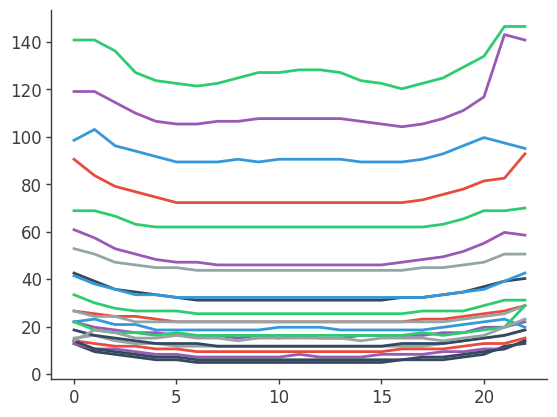

In [158]:
for i in response_bins_containment.keys():
    containment_deg = np.degrees(response_bins_containment[i])
    plt.plot(np.arange(len(containment_deg)),containment_deg,label=f'nh_{i}')

In [159]:
def get_expcountmap(ltdata,ltbkg,hawc_mask):
    """
    Computing the expected count maps and applying a mask

    Parameters:
        - ltdata : Long-Term observed counts for an analysis bin
        - ltbkg  : Long-Term background counts for an analysis bin
        - stbkg  : Short-Term background counts for an analysis bin
    Return:
        - expcount: Expected count map
    All the maps are smoothed previously, and masked
    """
    expcount = (ltdata-ltbkg)/np.sqrt(ltbkg)
    # np.place(expcount,np.isnan(expcount),0)
    # expcount = np.floor(stbkg.data*ltdata.data/ltbkg.data)
    # expcount = (stbkg.data*ltdata.data/ltbkg.data).astype(int)
    # expcount = np.floor(stbkg.data*ltdata.data/ltbkg.data).astype(int)
    # expcount = stbkg.data*ltdata.data/ltbkg.data
    expcount = hp.ma(expcount)
    expcount.mask = hawc_mask

    return expcount
def get_excessmaps(ltmaps,mask,annalysis_bins):
    """
    Get all expected maps
    """
    ecmaps = collections.OrderedDict()

    for binid in annalysis_bins:
        ecmap = get_expcountmap(
            ltmaps[f'{binid}-data'],
            ltmaps[f'{binid}-bkg'],
            mask
        )

        ecmaps[binid] = ecmap

    return ecmaps

In [165]:
analysis_bins = [
    'B0C0','B0C1','B1C0','B1C1',
    'B2C0','B2C1','B3C0','B3C1',
    'B4C0','B4C1','B5C0','B5C1',
    'B6C0','B6C1','B7C0','B7C1',
    'B8C0','B8C1','B9C0','B9C1',
    'B10C0','B10C1'
]
len(analysis_bins)

22

In [171]:
analysis_bins = ['B7C0','B7C1',
    'B8C0','B8C1','B9C0','B9C1',
    'B10C0','B10C1'
]
len(analysis_bins)

8

In [196]:
import os
def read_ltmaps(path_to_maps,analysis_bins,mask):

    ltmaps = collections.OrderedDict()
    for binid in analysis_bins:
        file_path = os.path.join(path_to_maps,f'bin{binid}-rejiggered.fits.gz')
        if os.path.exists(file_path):
            fname = os.path.join(path_to_maps,f'bin{binid}-rejiggered.fits.gz')
        else:
            fname = os.path.join(path_to_maps,f'bin{binid}-randomized-rejiggered.fits.gz')
        # try:
        #     file_path = os.path.join(path_to_maps,f'bin{binid}-rejiggered.fits.gz')
        #     if os.path.exists(file_path):
        #         fname = os.path.join(path_to_maps,f'bin{binid}-rejiggered.fits.gz')
        #         print(fname, binid)
        #         data,bkg = hp.read_map(fname,field=[0,1])
        # except:
        #     file_path = os.path.join(path_to_maps,f'bin{binid}-randomized-rejiggered.fits.gz')
        #     if os.path.exists(file_path):
        #         fname = os.path.join(path_to_maps,f'bin{binid}-randomized-rejiggered.fits.gz')
        #         print(fname, binid)
        #         data,bkg = hp.read_map(fname,field=[0,1])
        print(fname, binid)
        data,bkg = hp.read_map(fname,field=[0,1])
        # data = hp.read_map(fname,field=0)

        data = hp.ma(data)
        bkg  = hp.ma(bkg)

        data.mask = mask
        bkg.mask  = mask

        ltmaps[f'{binid}-data'] = data
        ltmaps[f'{binid}-bkg']  = bkg

    return ltmaps

In [197]:
path_to_ltmaps = '/Users/rishi/Documents/Analysis/data/countmaps/'
ltmaps   = read_ltmaps(path_to_ltmaps,analysis_bins,hawcmask)
expected_maps = get_excessmaps(ltmaps,hawcmask,analysis_bins)

/Users/rishi/Documents/Analysis/data/countmaps/binB7C0-rejiggered.fits.gz B7C0
/Users/rishi/Documents/Analysis/data/countmaps/binB7C1-randomized-rejiggered.fits.gz B7C1
/Users/rishi/Documents/Analysis/data/countmaps/binB8C0-randomized-rejiggered.fits.gz B8C0
/Users/rishi/Documents/Analysis/data/countmaps/binB8C1-randomized-rejiggered.fits.gz B8C1
/Users/rishi/Documents/Analysis/data/countmaps/binB9C0-randomized-rejiggered.fits.gz B9C0
/Users/rishi/Documents/Analysis/data/countmaps/binB9C1-randomized-rejiggered.fits.gz B9C1
/Users/rishi/Documents/Analysis/data/countmaps/binB10C0-randomized-rejiggered.fits.gz B10C0
/Users/rishi/Documents/Analysis/data/countmaps/binB10C1-randomized-rejiggered.fits.gz B10C1


In [213]:
sum_map = np.zeros(expected_maps[i].data.shape)
print(sum_map)
for i in expected_maps.keys():
    sum_map=+expected_maps[i].data

[0. 0. 0. ... 0. 0. 0.]


In [214]:
sum_map

array([0., 0., 0., ..., 0., 0., 0.])

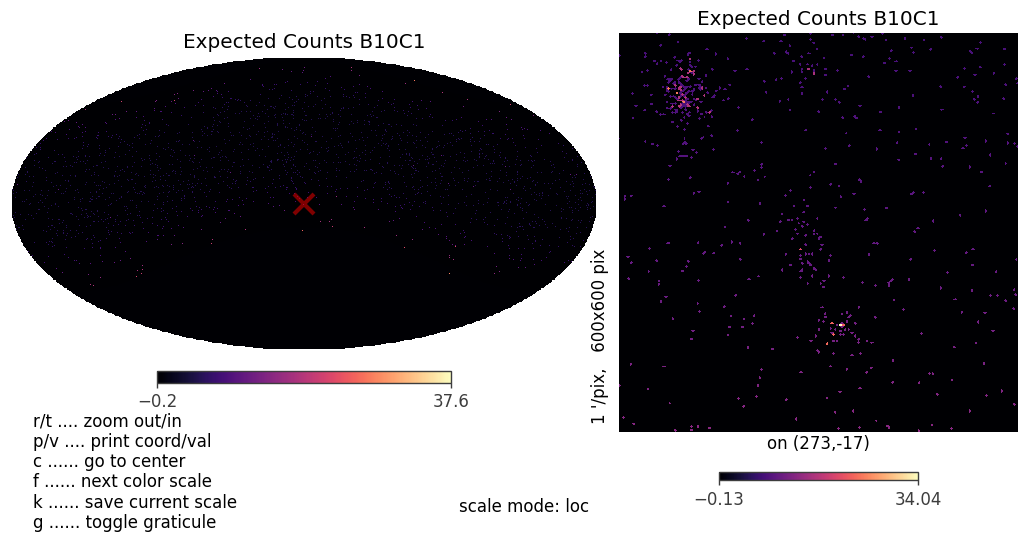

In [218]:
testbin = 'B10C1'
ra  = 273
dec = -17
hp.mollzoom(expected_maps[testbin].data,rot=[ra,dec,0],cmap='magma',title=f'Expected Counts {testbin}')

In [59]:
def get_logl_map(expectedobs,stmap,mask):

    print("AAAAA")
    # Change the null hypothesis and alternative hypothesis
    l_exp = np.log(poisson.pmf(stmap,expectedobs))
    l_exp = hp.ma(l_exp)
    l_obs = np.log(poisson.pmf(stmap,stmap))
    l_obs = hp.ma(l_obs)

    l_exp.mask = mask
    l_obs.mask = mask
    print("BBB")
    return l_obs,l_exp

def loglmaps(expected_maps, ltmaps,mask,analysis_bins):

    # llrmaps = collections.OrderedDict()
    llomaps = collections.OrderedDict()
    llemaps = collections.OrderedDict()

    for binid in analysis_bins:
        print(f"Bin {binid} ")
        lomap,lemap = get_logl_map(
            expected_maps[binid],
            ltmaps[f'{binid}-data'],
            mask
        )
        print(f"Bin {binid} Done 1")
        llomaps[binid] = lomap
        llemaps[binid] = lemap
        print(f"Bin {binid} Done")
    return llomaps,llemaps


def get_ts_map(llomaps,llemaps,analysis_bins,mask):

    tk = list(llomaps.keys())[0]

    llobs_tot = np.zeros_like(llomaps[tk].data,dtype=float)
    llexp_tot = np.zeros_like(llomaps[tk].data,dtype=float)

    for binid in analysis_bins:
        llobs_tot += llomaps[binid]
        llexp_tot += llemaps[binid]

    llexp_tot = hp.ma(llexp_tot)
    llobs_tot = hp.ma(llobs_tot)

    llobs_tot.mask = mask
    llexp_tot.mask = mask

    llratio = -2*(llexp_tot-llobs_tot)
    llratio = hp.ma(llratio)
    llratio.mask = mask

    return llratio


In [60]:
llobs,llexp = loglmaps(expected_maps,ltmaps,hawcmask,analysis_bins)

Bin B3C0 
AAAAA



WARNING RuntimeWarning: divide by zero encountered in log



BBB
Bin B3C0 Done 1
Bin B3C0 Done
Bin B4C0 
AAAAA



WARNING RuntimeWarning: divide by zero encountered in log



BBB
Bin B4C0 Done 1
Bin B4C0 Done
